In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
sns.set()

In [2]:
df_train = pd.read_csv("../../data/dtec/dTEC_train.csv", index_col=0)
df_test = pd.read_csv("../../data/dtec/dTEC_test.csv", index_col=0)

In [3]:
df_train.head()

,Time,SatID,dTEC,Class,Event_name,StationID,dTEC-10,dTEC-9,dTEC-8,dTEC-7,dTEC-6,dTEC-5,dTEC-4,dTEC-3,dTEC-2,dTEC-1
0,3/11/2011 5:05,G15,-0.055487,0,Tohoku,J0041,-0.000381,0.003298,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487
1,3/11/2011 5:06,G15,0.028164,0,Tohoku,J0041,0.003298,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164
2,3/11/2011 5:06,G15,0.078863,0,Tohoku,J0041,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863
3,3/11/2011 5:07,G15,0.011011,0,Tohoku,J0041,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863,0.011011
4,3/11/2011 5:07,G15,-0.067521,0,Tohoku,J0041,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863,0.011011,-0.067521


In [4]:
df_test.head()

,Time,SatID,dTEC,Class,Event_name,StationID,dTEC-10,dTEC-9,dTEC-8,dTEC-7,dTEC-6,dTEC-5,dTEC-4,dTEC-3,dTEC-2,dTEC-1
0,1/15/2022 3:05,G10,-0.059215,0,Tonga,LAUT,0.074218,0.041935,0.009234,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215
1,1/15/2022 3:05,G10,-0.059376,0,Tonga,LAUT,0.041935,0.009234,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376
2,1/15/2022 3:06,G10,-0.061546,0,Tonga,LAUT,0.009234,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376,-0.061546
3,1/15/2022 3:06,G10,-0.069589,0,Tonga,LAUT,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376,-0.061546,-0.069589
4,1/15/2022 3:07,G10,-0.083846,0,Tonga,LAUT,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376,-0.061546,-0.069589,-0.083846


In [5]:
set(df_test[df_test['Event_name'] == 'Tonga']['StationID'])

{'LAUT'}

In [6]:
set(df_train['Event_name'])

{'Alaska_18', 'Tohoku'}

In [7]:
tohoku = df_train[df_train['Event_name'] == 'Tohoku']
tk_one = tohoku[tohoku['SatID'] == 'G15']
tk_two = tohoku[tohoku['SatID'] == 'G26']
tk_one['Time'] = pd.to_datetime(tk_one['Time'])
tk_two['Time'] = pd.to_datetime(tk_two['Time'])
drop_cols = []
for i in range(1, 11):
    drop_cols.append('dTEC-'+str(i))
tk_one = tk_one.drop(drop_cols, axis=1)
tk_two = tk_two.drop(drop_cols, axis=1)
tk_one = tk_one.drop(['SatID', 'Event_name'], axis=1)
tk_two = tk_two.drop(['SatID', 'Event_name'], axis=1)
tk_one.shape, tk_two.shape

/tmp/ipykernel_52453/643960970.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tk_one['Time'] = pd.to_datetime(tk_one['Time'])
/tmp/ipykernel_52453/643960970.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tk_two['Time'] = pd.to_datetime(tk_two['Time'])


((1505, 4), (1374, 4))

In [8]:
tk_one_piv = tk_one.pivot(columns='StationID', values='dTEC')
tk_two_piv = tk_two.pivot(columns='StationID', values='dTEC')
tk_one_piv.tail()

StationID,J0041,J0170,J0533,J0581,J0944
344,0.035249,0.052440,-0.069213,NaN,NaN
345,0.120603,-0.032704,-0.082307,NaN,NaN
346,0.041735,-0.013182,0.002478,NaN,NaN
347,0.023403,0.072152,-0.054370,NaN,NaN
348,-0.000545,-0.001982,0.001316,NaN,NaN


In [9]:
tk_two_piv.tail()

StationID,J0041,J0170,J0533,J0581,J0944,J0947
224,-0.046204,-0.009367,0.073906,0.057156,0.009555,-0.026951
225,0.021417,0.000653,0.027506,0.092100,0.105009,-0.003223
226,0.001172,0.046181,-0.049919,0.060817,0.125051,0.016514
227,-0.152393,0.063252,-0.043045,0.115960,0.151383,0.020348
228,0.000810,-0.000421,-0.000308,0.000665,0.001479,0.010301


In [10]:
tk_one_time_piv = tk_one.pivot(columns='StationID', values='Time')
tk_two_time_piv = tk_two.pivot(columns='StationID', values='Time')
tk_one_class_piv = tk_one.pivot(columns='StationID', values='Class')
tk_two_class_piv = tk_two.pivot(columns='StationID', values='Class')

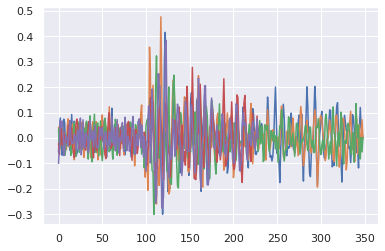

In [11]:
plt.plot(tk_one_piv.values)

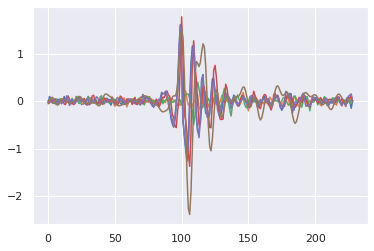

In [12]:
plt.plot(tk_two_piv.values)

In [13]:
tk_one_time_piv.head()

StationID,J0041,J0170,J0533,J0581,J0944
0,2011-03-11 05:05:00,2011-03-11 05:05:00,2011-03-11 05:05:00,2011-03-11 05:05:00,2011-03-11 05:05:00
1,2011-03-11 05:06:00,2011-03-11 05:06:00,2011-03-11 05:06:00,2011-03-11 05:06:00,2011-03-11 05:06:00
2,2011-03-11 05:06:00,2011-03-11 05:06:00,2011-03-11 05:06:00,2011-03-11 05:06:00,2011-03-11 05:06:00
3,2011-03-11 05:07:00,2011-03-11 05:07:00,2011-03-11 05:07:00,2011-03-11 05:07:00,2011-03-11 05:07:00
4,2011-03-11 05:07:00,2011-03-11 05:07:00,2011-03-11 05:07:00,2011-03-11 05:07:00,2011-03-11 05:07:00


In [14]:
tk_one_time_piv.tail()

StationID,J0041,J0170,J0533,J0581,J0944
344,2011-03-11 07:57:00,2011-03-11 07:57:00,2011-03-11 07:57:00,NaT,NaT
345,2011-03-11 07:58:00,2011-03-11 07:58:00,2011-03-11 07:58:00,NaT,NaT
346,2011-03-11 07:58:00,2011-03-11 07:58:00,2011-03-11 07:58:00,NaT,NaT
347,2011-03-11 07:59:00,2011-03-11 07:59:00,2011-03-11 07:59:00,NaT,NaT
348,2011-03-11 07:59:00,2011-03-11 07:59:00,2011-03-11 07:59:00,NaT,NaT


In [15]:
tk_two_time_piv.tail()

StationID,J0041,J0170,J0533,J0581,J0944,J0947
224,2011-03-11 06:57:00,2011-03-11 06:57:00,2011-03-11 06:57:00,2011-03-11 06:57:00,2011-03-11 06:57:00,2011-03-11 06:57:00
225,2011-03-11 06:58:00,2011-03-11 06:58:00,2011-03-11 06:58:00,2011-03-11 06:58:00,2011-03-11 06:58:00,2011-03-11 06:58:00
226,2011-03-11 06:58:00,2011-03-11 06:58:00,2011-03-11 06:58:00,2011-03-11 06:58:00,2011-03-11 06:58:00,2011-03-11 06:58:00
227,2011-03-11 06:59:00,2011-03-11 06:59:00,2011-03-11 06:59:00,2011-03-11 06:59:00,2011-03-11 06:59:00,2011-03-11 06:59:00
228,2011-03-11 06:59:00,2011-03-11 06:59:00,2011-03-11 06:59:00,2011-03-11 06:59:00,2011-03-11 06:59:00,2011-03-11 06:59:00


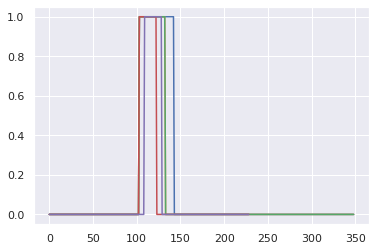

In [16]:
plt.plot(tk_one_class_piv.values)

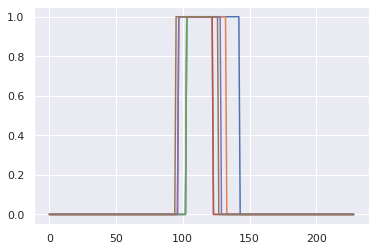

In [17]:
plt.plot(tk_two_class_piv.values)

In [18]:
tk_class_piv = tk_two.pivot(columns='StationID', values='Class')

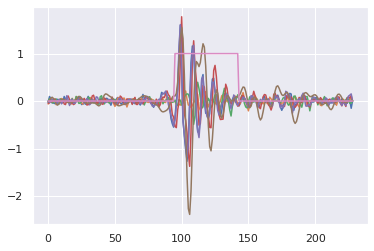

In [19]:
plt.plot(tk_two_piv)
plt.plot(tk_class_piv.max(axis=1))

In [20]:
np.savetxt('../../data/dtec/tk_two.csv', tk_two_piv.values, delimiter=",")

In [21]:
df_train[df_train['Event_name'] == 'Tohoku']

,Time,SatID,dTEC,Class,Event_name,StationID,dTEC-10,dTEC-9,dTEC-8,dTEC-7,dTEC-6,dTEC-5,dTEC-4,dTEC-3,dTEC-2,dTEC-1
0,3/11/2011 5:05,G15,-0.055487,0,Tohoku,J0041,-0.000381,0.003298,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487
1,3/11/2011 5:06,G15,0.028164,0,Tohoku,J0041,0.003298,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164
2,3/11/2011 5:06,G15,0.078863,0,Tohoku,J0041,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863
3,3/11/2011 5:07,G15,0.011011,0,Tohoku,J0041,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863,0.011011
4,3/11/2011 5:07,G15,-0.067521,0,Tohoku,J0041,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863,0.011011,-0.067521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,3/11/2011 6:57,G26,-0.026951,0,Tohoku,J0947,0.017678,0.094908,0.139820,0.145810,0.117641,0.068466,0.015877,-0.023067,-0.037399,-0.026951
225,3/11/2011 6:58,G26,-0.003223,0,Tohoku,J0947,0.094908,0.139820,0.145810,0.117641,0.068466,0.015877,-0.023067,-0.037399,-0.026951,-0.003223
226,3/11/2011 6:58,G26,0.016514,0,Tohoku,J0947,0.139820,0.145810,0.117641,0.068466,0.015877,-0.023067,-0.037399,-0.026951,-0.003223,0.016514
227,3/11/2011 6:59,G26,0.020348,0,Tohoku,J0947,0.145810,0.117641,0.068466,0.015877,-0.023067,-0.037399,-0.026951,-0.003223,0.016514,0.020348


In [22]:
alaska = df_train[df_train['Event_name'] == 'Alaska_18']
alaska['Time'] = pd.to_datetime(alaska['Time'])
drop_cols = []
for i in range(1, 11):
    drop_cols.append('dTEC-'+str(i))
alaska = alaska.drop(drop_cols, axis=1)
alaska = alaska.drop(['SatID', 'Event_name'], axis=1)
alaska.head()

/tmp/ipykernel_52453/1054522899.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alaska['Time'] = pd.to_datetime(alaska['Time'])


,Time,dTEC,Class,StationID
0,2018-01-23 09:17:00,-0.024716,0,AV06
1,2018-01-23 09:17:00,-0.003521,0,AV06
2,2018-01-23 09:18:00,0.015844,0,AV06
3,2018-01-23 09:18:00,0.011721,0,AV06
4,2018-01-23 09:18:00,-0.000781,0,AV06


In [23]:
alaska_piv = alaska.pivot(columns='StationID', values='dTEC')
alaska_piv.tail()

StationID,AV06,AV07,AV09,AV10,AV26
405,-0.000778,NaN,NaN,NaN,0.011657
406,0.005440,NaN,NaN,NaN,0.014832
407,-0.000231,NaN,NaN,NaN,0.009327
408,-0.007714,NaN,NaN,NaN,0.002175
409,-0.000073,NaN,NaN,NaN,-0.000158


In [24]:
alaska_time_piv = alaska.pivot(columns='StationID', values='Time')
alaska_time_piv

StationID,AV06,AV07,AV09,AV10,AV26
0,2018-01-23 09:17:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:17:00
1,2018-01-23 09:17:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:17:00
2,2018-01-23 09:18:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:18:00
3,2018-01-23 09:18:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:18:00
4,2018-01-23 09:18:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:18:00
...,...,...,...,...,...
405,2018-01-23 10:58:00,NaT,NaT,NaT,2018-01-23 10:58:00
406,2018-01-23 10:59:00,NaT,NaT,NaT,2018-01-23 10:59:00
407,2018-01-23 10:59:00,NaT,NaT,NaT,2018-01-23 10:59:00
408,2018-01-23 10:59:00,NaT,NaT,NaT,2018-01-23 10:59:00


In [25]:
alaska_class_piv = alaska.pivot(columns='StationID', values='Class')
#alaska_class_piv = alaska_class_piv.iloc[0:390, :]
last_idx = 390
length = alaska_class_piv.shape[0]
shift_stations = ['AV07', 'AV09', 'AV10']
for stat in shift_stations:
    alaska_piv.loc[:, stat] = alaska_piv.loc[:, stat].shift(length-last_idx)
    alaska_class_piv.loc[:, stat] = alaska_class_piv.loc[:, stat].shift(length-last_idx)
    alaska_time_piv.loc[:, stat] = alaska_time_piv.loc[:, stat].shift(length-last_idx)
alaska_piv = alaska_piv.iloc[length-last_idx:, :]
alaska_class_piv = alaska_class_piv.iloc[length-last_idx:, :]
alaska_time_piv = alaska_time_piv.iloc[length-last_idx:, :]
alaska_class_piv.tail()

StationID,AV06,AV07,AV09,AV10,AV26
405,0.0,0.0,0.0,0.0,0.0
406,0.0,0.0,0.0,0.0,0.0
407,0.0,0.0,0.0,0.0,0.0
408,0.0,0.0,0.0,0.0,0.0
409,0.0,0.0,0.0,0.0,0.0


In [26]:
alaska_class_piv.head()

StationID,AV06,AV07,AV09,AV10,AV26
20,0.0,0.0,0.0,0.0,0.0
21,0.0,0.0,0.0,0.0,0.0
22,0.0,0.0,0.0,0.0,0.0
23,0.0,0.0,0.0,0.0,0.0
24,0.0,0.0,0.0,0.0,0.0


In [27]:
alaska_class_piv.isnull().any()

StationID
AV06    False
AV07    False
AV09    False
AV10    False
AV26    False
dtype: bool

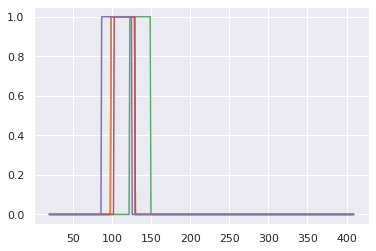

In [28]:
plt.plot(alaska_class_piv)

In [29]:
alaska_time_piv.tail()

StationID,AV06,AV07,AV09,AV10,AV26
405,2018-01-23 10:58:00,2018-01-23 10:58:00,2018-01-23 10:58:00,2018-01-23 10:58:00,2018-01-23 10:58:00
406,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00
407,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00
408,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00
409,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00,2018-01-23 10:59:00


In [30]:
alaska_time_piv.head()

StationID,AV06,AV07,AV09,AV10,AV26
20,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00
21,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00,2018-01-23 09:22:00
22,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00
23,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00
24,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00,2018-01-23 09:23:00


In [31]:
alaska_piv.tail()

StationID,AV06,AV07,AV09,AV10,AV26
405,-0.000778,-0.002612,-0.012221,0.007458,0.011657
406,0.005440,-0.007039,-0.012882,0.010342,0.014832
407,-0.000231,-0.007840,0.013121,-0.023235,0.009327
408,-0.007714,-0.007433,0.025371,-0.055322,0.002175
409,-0.000073,0.000613,-0.000490,0.000723,-0.000158


In [32]:
alaska_piv.head()

StationID,AV06,AV07,AV09,AV10,AV26
20,0.004930,-0.015874,-0.032466,-0.009529,0.008428
21,0.011791,-0.003493,-0.024800,-0.021190,0.006509
22,0.005906,0.018676,-0.027544,-0.003311,-0.005410
23,0.001682,0.020276,-0.029461,-0.005799,-0.022686
24,0.004521,0.002334,0.001592,-0.017962,-0.026039


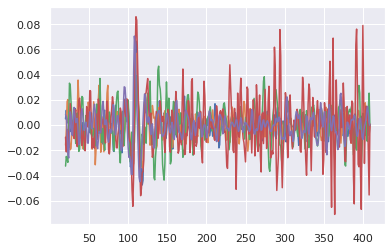

In [33]:
plt.plot(alaska_piv)

In [34]:
scaler = StandardScaler()
alaska_vals = scaler.fit_transform(alaska_piv.values)

In [35]:
print(alaska_vals.shape)

(390, 5)


In [36]:
np.savetxt('../../data/dtec/alaska.csv', alaska_vals, delimiter=",")

In [37]:
np.linalg.det(np.cov(alaska_vals.T))

0.5577808096452395

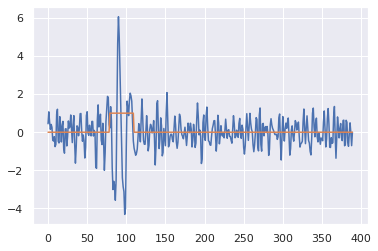

In [38]:
plt.plot(alaska_vals[:, 0])
plt.plot(alaska_class_piv.values[:, 0])

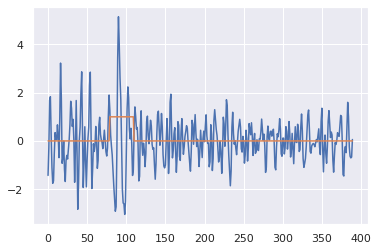

In [39]:
plt.plot(alaska_vals[:, 1])
plt.plot(alaska_class_piv.values[:, 1])

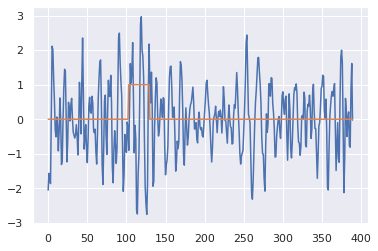

In [40]:
plt.plot(alaska_vals[:, 2])
plt.plot(alaska_class_piv.values[:, 2])

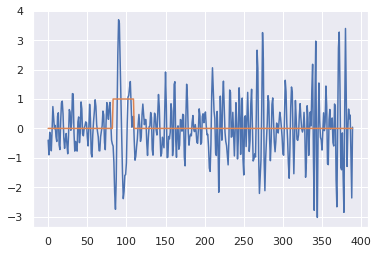

In [41]:
plt.plot(alaska_vals[:, 3])
plt.plot(alaska_class_piv.values[:, 3])

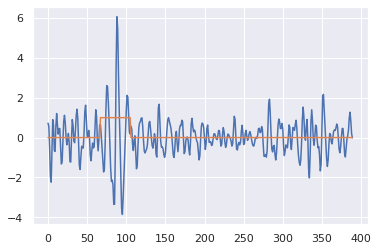

In [42]:
plt.plot(alaska_vals[:, 4])
plt.plot(alaska_class_piv.values[:, 4])

In [43]:
alaska_lrt = np.loadtxt("/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/alaska/lrt_results.csv", delimiter=',')
alaska_lrt.shape

(290, 6)

In [44]:
tohoku_lrt = np.loadtxt("/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/tohoku/lrt_results.csv", delimiter=',')
tohoku_lrt.shape

(189, 6)

In [45]:
alaska_lrt_padded = np.pad(alaska_lrt, [(50, 50), (0,0)], mode='constant')[:, 0:3]
tohoku_lrt_padded = np.pad(tohoku_lrt, [(20, 20), (0, 0)], mode='constant')[:, 0:3]
alaska_lrt_padded.shape, tohoku_lrt_padded.shape

((390, 3), (229, 3))

In [46]:
alaska_time = pd.to_datetime(alaska_time_piv.iloc[:, 0])

In [47]:
first_ak = alaska_time[np.where(alaska_class_piv.max(axis=1) != 0)[0][0]]
last_ak = alaska_time[np.where(alaska_class_piv.max(axis=1) != 0)[0][-1]]

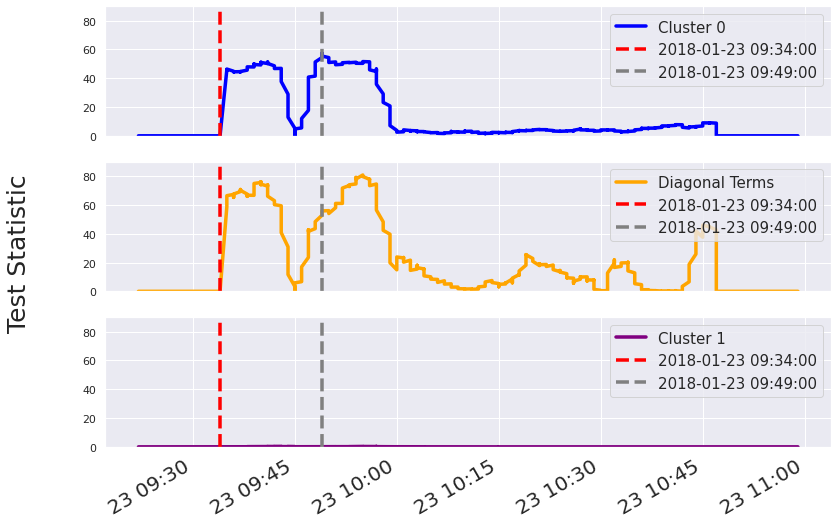

In [66]:
fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True, sharey=True)
ax[0].plot(alaska_time, alaska_lrt_padded[:, 0], color='blue', label='Cluster 0', linewidth=3.5)
ax[0].axvline(x=first_ak, ls='--', color='red', label=str(first_ak), linewidth=3.5)
ax[0].axvline(x=last_ak, ls='--', color='gray', label=str(last_ak), linewidth=3.5)
ax[0].legend(loc='best', fontsize=15)
ax[0].set_ylim(0, 90)
#ax[0].set_ylabel("Test Statistic", fontsize=25)
ax[1].plot(alaska_time, alaska_lrt_padded[:, 2], color='orange', label='Diagonal Terms', linewidth=3.5)
ax[1].axvline(x=first_ak, ls='--', color='red', label=str(first_ak), linewidth=3.5)
ax[1].axvline(x=last_ak, ls='--', color='gray', label=str(last_ak), linewidth=3.5)
ax[1].legend(loc='best', fontsize=15)
ax[1].set_ylim(0, 90)
#ax[1].set_ylabel("Test Statistic", fontsize=25)
ax[2].plot(alaska_time, alaska_lrt_padded[:, 1], color='purple', label='Cluster 1', linewidth=3.5)
ax[2].axvline(x=first_ak, ls='--', color='red', label=str(first_ak), linewidth=3.5)
ax[2].axvline(x=last_ak, ls='--', color='gray', label=str(last_ak), linewidth=3.5)
ax[2].legend(loc='best', fontsize=15)
ax[2].set_ylim(0, 90)
#ax[2].set_ylabel("Test Statistic", fontsize=25)
fig.supylabel('Test Statistic', fontsize=25)
plt.gcf().autofmt_xdate()
plt.xticks(fontsize=20);
#plt.xlabel("Time", fontsize=25);

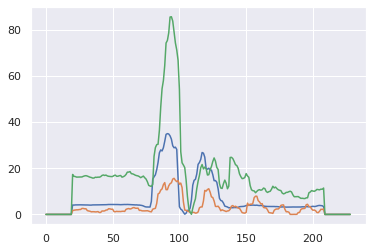

In [53]:
plt.plot(tohoku_lrt_padded)

In [68]:
tk_time = pd.to_datetime(tk_two_time_piv.iloc[:, 0])
first_tk = tk_time[np.where(tk_class_piv.max(axis=1) != 0)[0][0]]
last_tk = tk_time[np.where(tk_class_piv.max(axis=1) != 0)[0][-1]]

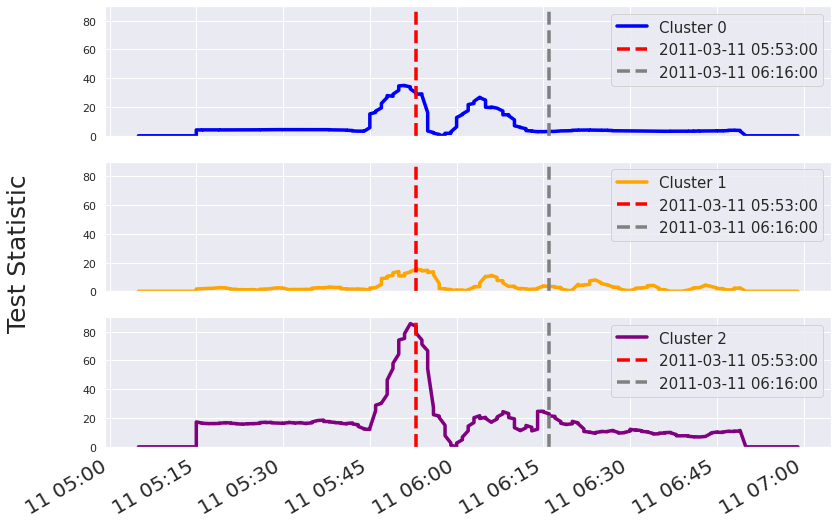

In [73]:
fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True, sharey=True)
ax[0].plot(tk_time, tohoku_lrt_padded[:, 0], color='blue', label='Cluster 0', linewidth=3.5)
ax[0].axvline(x=first_tk, ls='--', color='red', label=str(first_tk), linewidth=3.5)
ax[0].axvline(x=last_tk, ls='--', color='gray', label=str(last_tk), linewidth=3.5)
ax[0].legend(loc='best', fontsize=15)
ax[0].set_ylim(0, 90)
#ax[0].set_ylabel("Test Statistic", fontsize=12)
ax[1].plot(tk_time, tohoku_lrt_padded[:, 1], color='orange', label='Cluster 1', linewidth=3.5)
ax[1].axvline(x=first_tk, ls='--', color='red', label=str(first_tk), linewidth=3.5)
ax[1].axvline(x=last_tk, ls='--', color='gray', label=str(last_tk), linewidth=3.5)
ax[1].legend(loc='best', fontsize=15)
ax[1].set_ylim(0, 90)
#ax[1].set_ylabel("Test Statistic", fontsize=12)
ax[2].plot(tk_time, tohoku_lrt_padded[:, 2], color='purple', label='Cluster 2', linewidth=3.5)
ax[2].axvline(x=first_tk, ls='--', color='red', label=str(first_tk), linewidth=3.5)
ax[2].axvline(x=last_tk, ls='--', color='gray', label=str(last_tk), linewidth=3.5)
ax[2].legend(loc='best', fontsize=15)
ax[2].set_ylim(0, 90)
#ax[2].set_ylabel("Test Statistic", fontsize=12)
fig.supylabel('Test Statistic', fontsize=25)
plt.gcf().autofmt_xdate()
plt.xticks(fontsize=20);
#plt.xlabel("Time");